In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures

In [2]:
df = pd.read_csv('Student_Marks.csv')
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Dataset shape: (100, 3)

First 5 rows:
   number_courses  time_study   Marks
0               3       4.508  19.202
1               4       0.096   7.734
2               4       3.133  13.811
3               6       7.909  53.018
4               8       7.811  55.299


In [3]:
X = df[['time_study']].values
y = df['Marks'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")


Training set size: 80
Test set size: 20


In [7]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred_train = linear_model.predict(X_train)
y_pred_test = linear_model.predict(X_test)

r2_train = linear_model.score(X_train, y_train)
r2_test = linear_model.score(X_test, y_test)

print("\nLinear Regression Results (Degree 1)")
print(f"R2 Score (Training): {r2_train:.4f}")
print(f"R2 Score (Test): {r2_test:.4f}")


=== Linear Regression Results (Degree 1) ===
R2 Score (Training): 0.8740
R2 Score (Test): 0.9040


In [8]:
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)

print(f"MSE (Training): {mse_train:.4f}")
print(f"MSE (Test): {mse_test:.4f}")

print(f"\nLinear Model Coefficients:")
print(f"Intercept: {linear_model.intercept_:.4f}")
print(f"Coefficient for time_study: {linear_model.coef_[0]:.4f}")

MSE (Training): 22.9575
MSE (Test): 25.2367

Linear Model Coefficients:
Intercept: 2.5156
Coefficient for time_study: 5.3553


In [11]:
degrees = [1, 2, 3, 4]
results = []

for degree in degrees:
    #print(f"\n\nPolynomial Regression Results (Degree {degree})")
    
    if degree == 1:
        model = linear_model
        X_train_poly = X_train
        X_test_poly = X_test
    else:
        poly = PolynomialFeatures(degree=degree, include_bias=False)
        X_train_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(X_test)
        
        model = LinearRegression()
        model.fit(X_train_poly, y_train)
    
    y_pred_train = model.predict(X_train_poly)
    y_pred_test = model.predict(X_test_poly)
    
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)
    mse_train = mean_squared_error(y_train, y_pred_train)
    mse_test = mean_squared_error(y_test, y_pred_test)
    
    #print(f"R2 Score (Training): {r2_train:.4f}")
    #print(f"R2 Score (Test): {r2_test:.4f}")
    #print(f"MSE (Training): {mse_train:.4f}")
    #print(f"MSE (Test): {mse_test:.4f}")
    
    results.append({
        'Degree': degree,
        'R2_Train': r2_train,
        'R2_Test': r2_test,
        'MSE_Train': mse_train,
        'MSE_Test': mse_test
    })

results_df = pd.DataFrame(results)
print("Summary of All Models:")
print(results_df.to_string(index=False))



=== Summary of All Models ===
 Degree  R2_Train  R2_Test  MSE_Train  MSE_Test
      1  0.874010 0.904023  22.957504 25.236746
      2  0.949811 0.968307   9.145290  8.333458
      3  0.951306 0.963367   8.872816  9.632518
      4  0.951906 0.964878   8.763614  9.235289


In [12]:
print("Overfitting Analysis")
for i, result in enumerate(results):
    r2_diff = result['R2_Train'] - result['R2_Test']
    mse_ratio = result['MSE_Test'] / result['MSE_Train']
    
    print(f"\nDegree {result['Degree']}:")
    print(f"  R2 difference (Train - Test): {r2_diff:.4f}")
    print(f"  MSE ratio (Test/Train): {mse_ratio:.4f}")
    
    if r2_diff > 0.1 and mse_ratio > 1.5:
        print(f"Possible overfitting")
    elif r2_diff < 0.05:
        print(f"No overfitting")
    else:
        print(f"Slight overfitting")

=== Overfitting Analysis ===

Degree 1:
  R2 difference (Train - Test): -0.0300
  MSE ratio (Test/Train): 1.0993
No overfitting

Degree 2:
  R2 difference (Train - Test): -0.0185
  MSE ratio (Test/Train): 0.9112
No overfitting

Degree 3:
  R2 difference (Train - Test): -0.0121
  MSE ratio (Test/Train): 1.0856
No overfitting

Degree 4:
  R2 difference (Train - Test): -0.0130
  MSE ratio (Test/Train): 1.0538
No overfitting


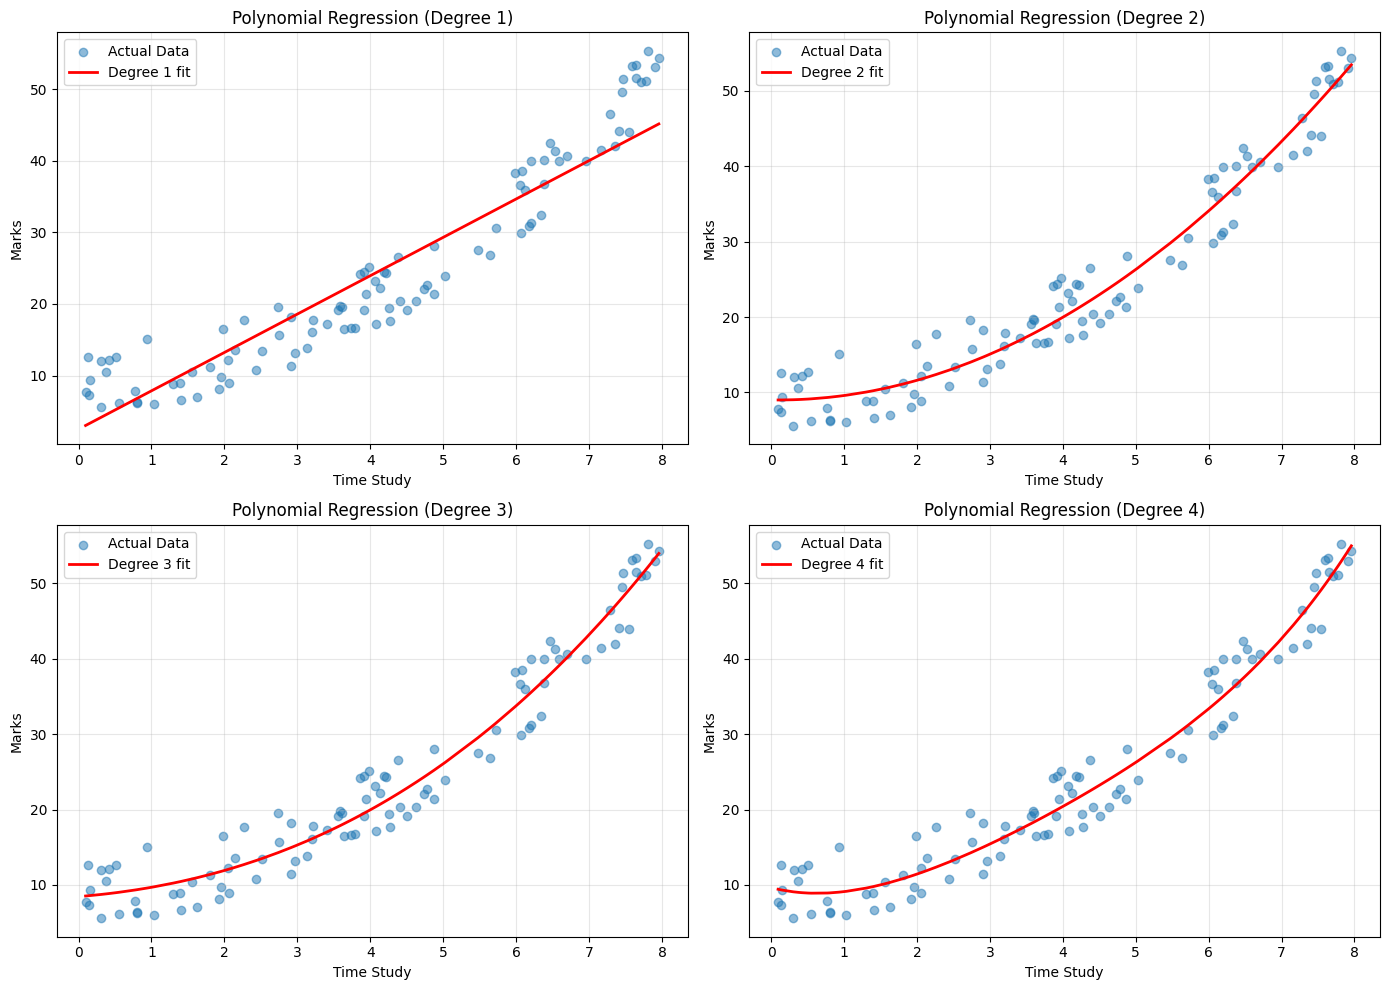

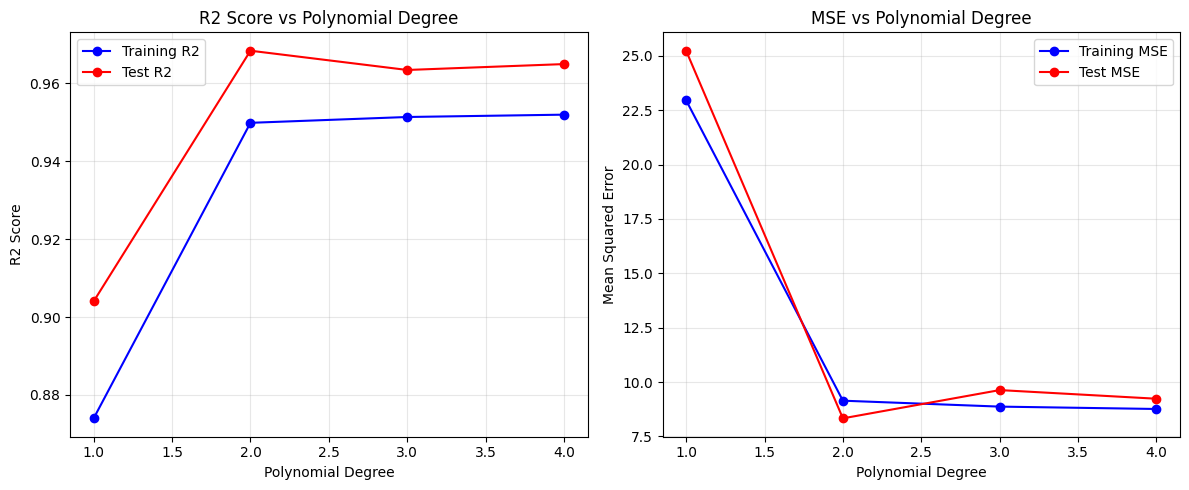

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, degree in enumerate(degrees):
    if degree == 1:
        X_poly = X
        model = linear_model
    else:
        poly = PolynomialFeatures(degree=degree, include_bias=False)
        X_poly = poly.fit_transform(X)
        model = LinearRegression()
        model.fit(X_poly, y)
    
    X_sorted = np.sort(X, axis=0)
    if degree == 1:
        X_sorted_poly = X_sorted
    else:
        X_sorted_poly = poly.transform(X_sorted)
    
    y_sorted_pred = model.predict(X_sorted_poly)
    
    ax = axes[idx]
    ax.scatter(X, y, alpha=0.5, label='Actual Data')
    ax.plot(X_sorted, y_sorted_pred, 'r-', linewidth=2, label=f'Degree {degree} fit')
    ax.set_xlabel('Time Study')
    ax.set_ylabel('Marks')
    ax.set_title(f'Polynomial Regression (Degree {degree})')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(degrees, [r['R2_Train'] for r in results], 'bo-', label='Training R2')
ax1.plot(degrees, [r['R2_Test'] for r in results], 'ro-', label='Test R2')
ax1.set_xlabel('Polynomial Degree')
ax1.set_ylabel('R2 Score')
ax1.set_title('R2 Score vs Polynomial Degree')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(degrees, [r['MSE_Train'] for r in results], 'bo-', label='Training MSE')
ax2.plot(degrees, [r['MSE_Test'] for r in results], 'ro-', label='Test MSE')
ax2.set_xlabel('Polynomial Degree')
ax2.set_ylabel('Mean Squared Error')
ax2.set_title('MSE vs Polynomial Degree')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()